In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [2]:
df = pd.read_csv("data/spotify_cleaned.csv")

print(df.shape)
df.head()

(4692, 24)


,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_release_date,instrumentalness,mode,key,duration_ms,acousticness,playlist_subgenre,popularity_group,release_year,duration_min
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,2024-08-16,0.0000,0.0,6.0,251668.0,0.3080,mainstream,High,2024.0,4.194467
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,2024-05-17,0.0608,1.0,2.0,210373.0,0.2000,mainstream,High,2024.0,3.506217
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,2024-10-18,0.0000,1.0,1.0,166300.0,0.2140,mainstream,High,2024.0,2.771667
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,2024-08-23,0.0000,0.0,0.0,157280.0,0.0939,mainstream,High,2024.0,2.621333
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2024-10-18,0.0000,0.0,0.0,169917.0,0.0283,mainstream,High,2024.0,2.831950


In [3]:
df["track_album_release_date"] = pd.to_datetime(
    df["track_album_release_date"],
    errors="coerce"
)

df["release_year"] = df["track_album_release_date"].dt.year
df["duration_min"] = df["duration_ms"] / 60000

df["popularity_level"] = pd.cut(
    df["track_popularity"],
    bins=[0, 40, 70, 100],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

df.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,mode,key,duration_ms,acousticness,playlist_subgenre,popularity_group,release_year,duration_min,popularity_level
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,0.0000,0.0,6.0,251668.0,0.3080,mainstream,High,2024,4.194467,High
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,0.0608,1.0,2.0,210373.0,0.2000,mainstream,High,2024,3.506217,High
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,0.0000,1.0,1.0,166300.0,0.2140,mainstream,High,2024,2.771667,High
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,0.0000,0.0,0.0,157280.0,0.0939,mainstream,High,2024,2.621333,High
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,0.0000,0.0,0.0,169917.0,0.0283,mainstream,High,2024,2.831950,High


c:\Users\Duy  Thang\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


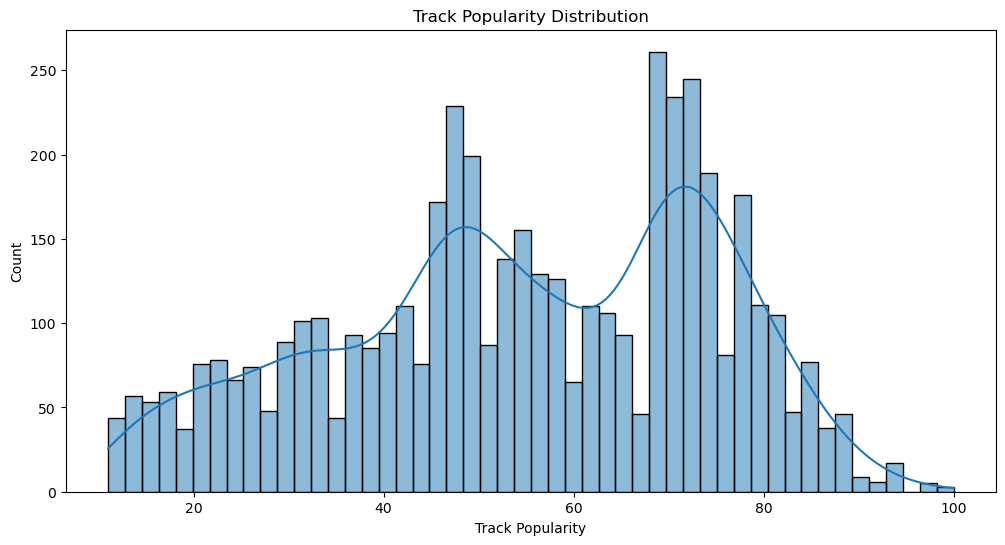

In [4]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df["track_popularity"],
    bins=50,
    kde=True
)

plt.title("Track Popularity Distribution")
plt.xlabel("Track Popularity")
plt.ylabel("Count")
plt.show()

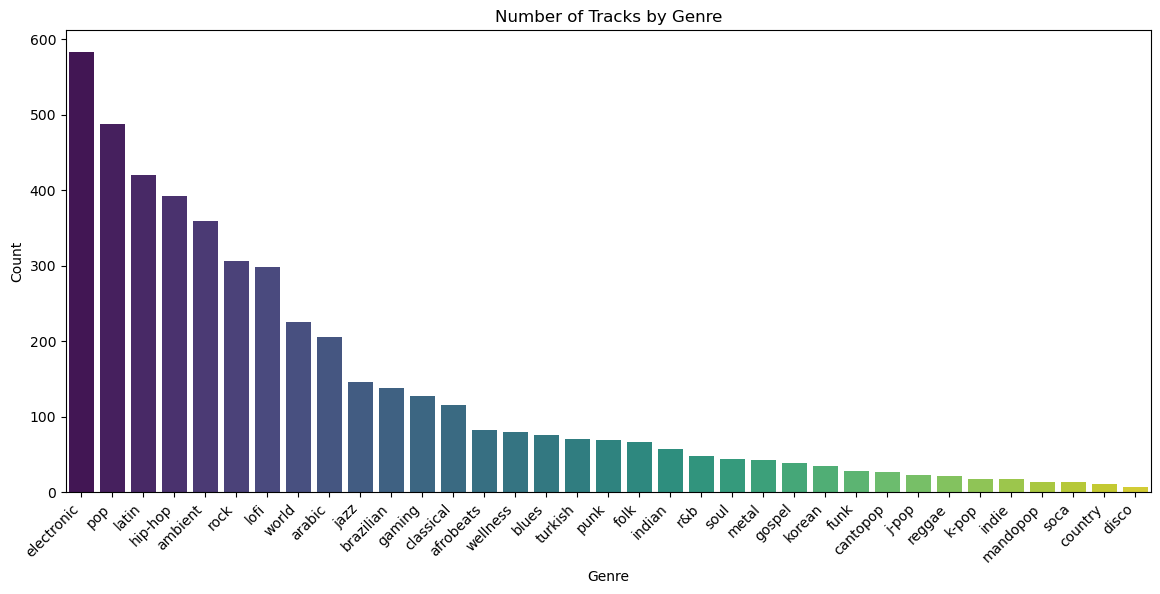

In [5]:
plt.figure(figsize=(14, 6))

genre_order = df["playlist_genre"].value_counts().index

sns.countplot(
    data=df,
    x="playlist_genre",
    order=genre_order,
    palette="viridis"
)

plt.title("Number of Tracks by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

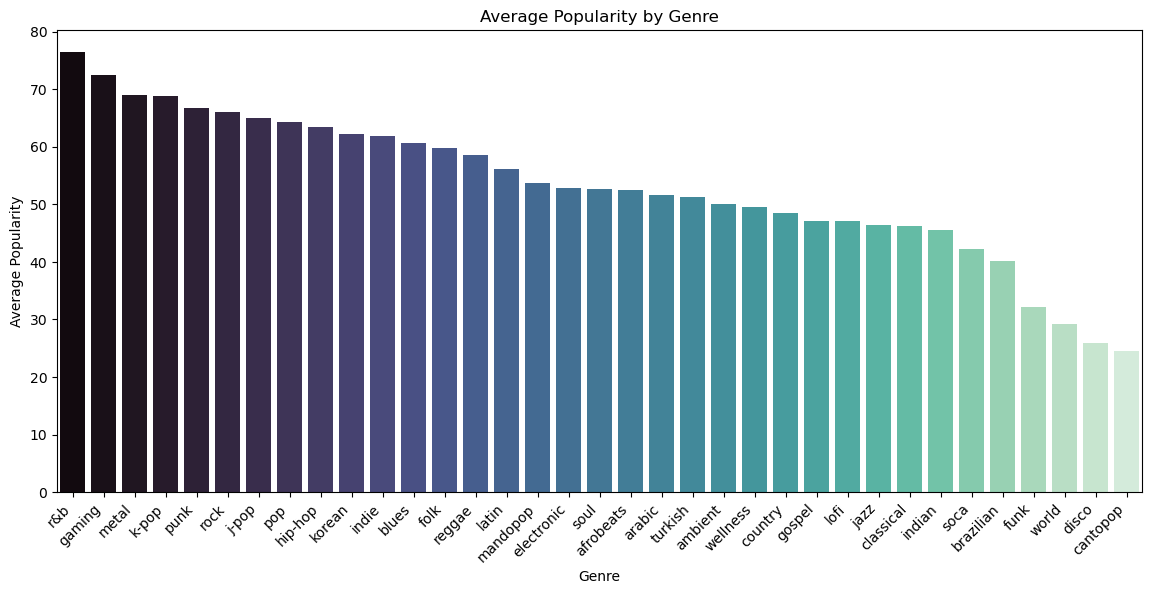

In [6]:
genre_pop = (
    df.groupby("playlist_genre")["track_popularity"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(14, 6))

sns.barplot(
    data=genre_pop,
    x="playlist_genre",
    y="track_popularity",
    palette="mako"
)

plt.title("Average Popularity by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45, ha="right")
plt.show()

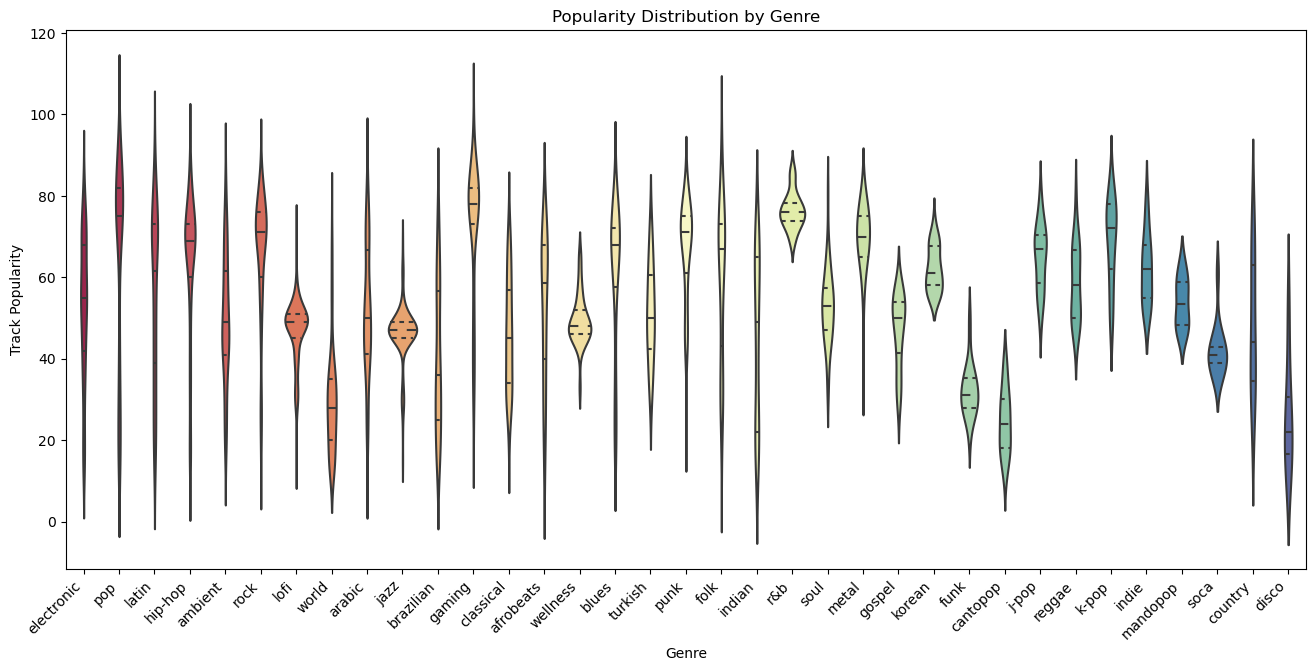

In [7]:
plt.figure(figsize=(16, 7))

sns.violinplot(
    data=df,
    x="playlist_genre",
    y="track_popularity",
    order=genre_order,
    palette="Spectral",
    inner="quartile"
)

plt.title("Popularity Distribution by Genre")
plt.xlabel("Genre")
plt.ylabel("Track Popularity")
plt.xticks(rotation=45, ha="right")
plt.show()

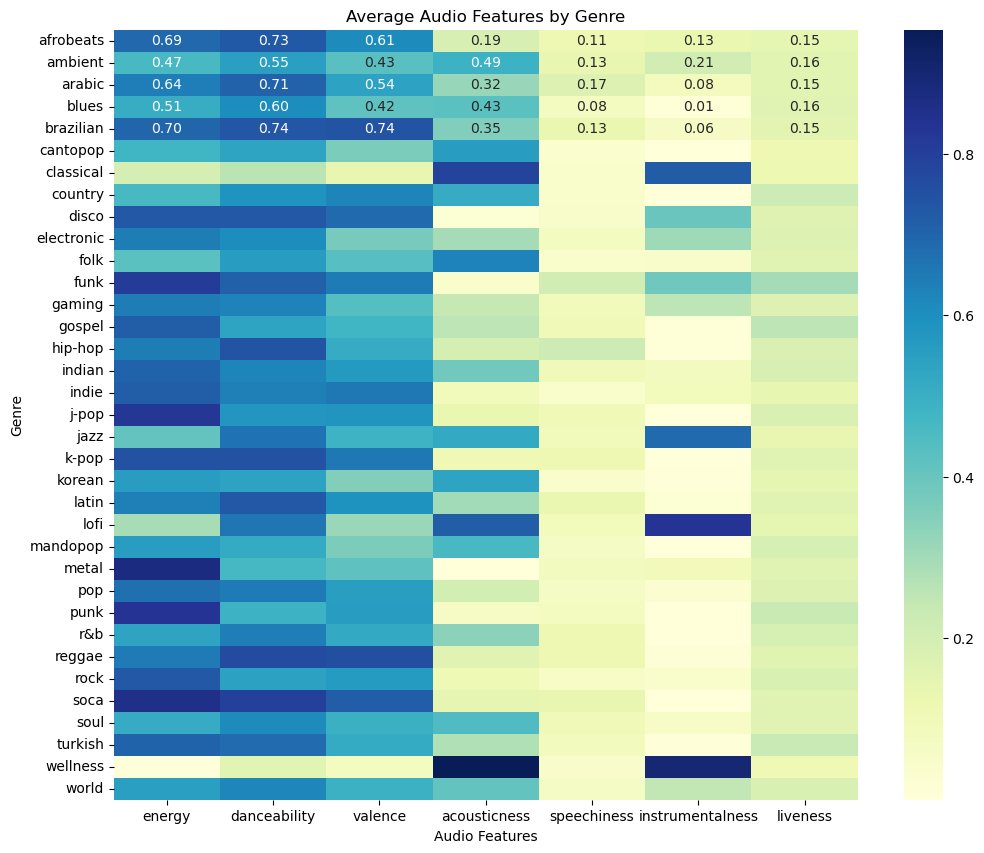

In [8]:
audio_features = [
    "energy",
    "danceability",
    "valence",
    "acousticness",
    "speechiness",
    "instrumentalness",
    "liveness"
]

genre_features = df.groupby("playlist_genre")[audio_features].mean()

plt.figure(figsize=(12, 10))

sns.heatmap(
    genre_features,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Average Audio Features by Genre")
plt.xlabel("Audio Features")
plt.ylabel("Genre")
plt.show()

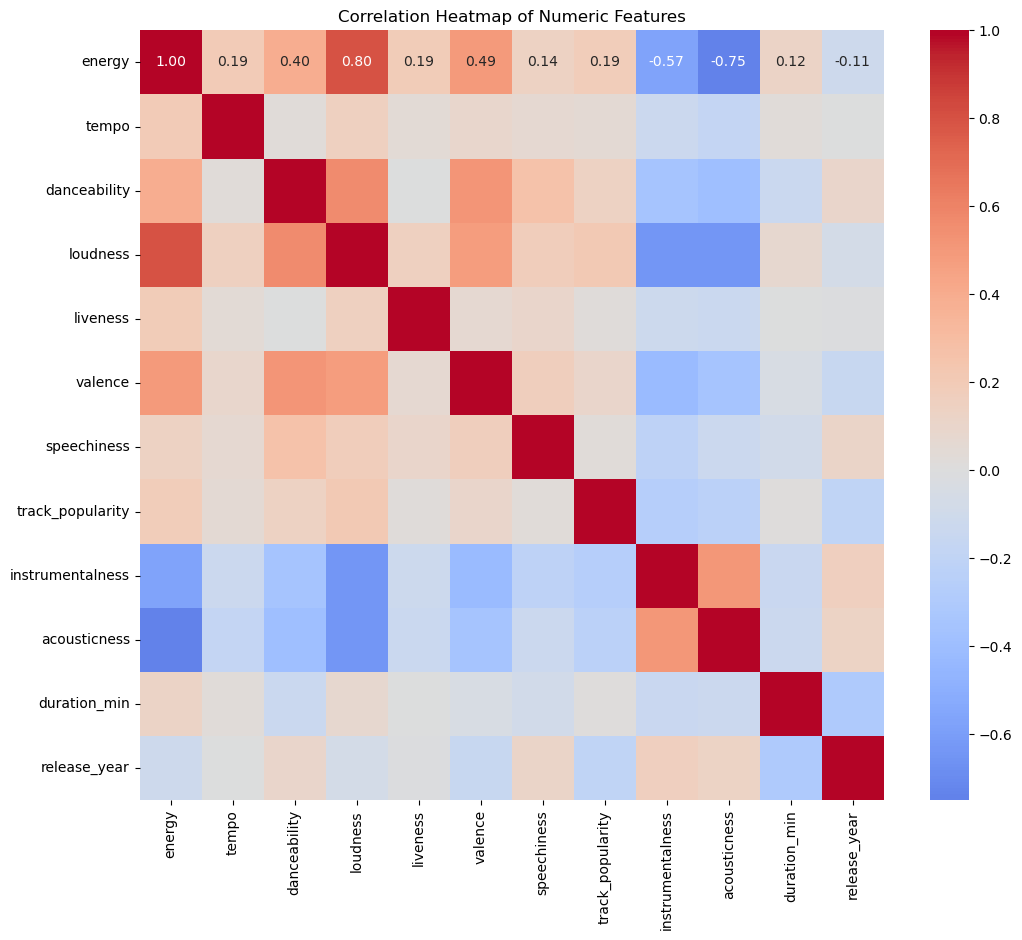

In [9]:
numeric_cols = [
    "energy",
    "tempo",
    "danceability",
    "loudness",
    "liveness",
    "valence",
    "speechiness",
    "track_popularity",
    "instrumentalness",
    "acousticness",
    "duration_min",
    "release_year"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numeric Features")
plt.show()

In [10]:
fig = px.treemap(
    df,
    path=["playlist_genre", "playlist_subgenre"],
    values=None,
    color="track_popularity",
    color_continuous_scale="Greens",
    title="Genre and Subgenre Structure by Popularity"
)

fig.show()

In [11]:
sunburst_df = (
    df.groupby(["playlist_genre", "playlist_subgenre", "popularity_level"])
    .size()
    .reset_index(name="count")
)

fig = px.sunburst(
    sunburst_df,
    path=["playlist_genre", "playlist_subgenre", "popularity_level"],
    values="count",
    color="popularity_level",
    title="Genre → Subgenre → Popularity Level"
)

fig.show()

C:\Users\Duy  Thang\AppData\Local\Temp\ipykernel_10592\2063384503.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

c:\Users\Duy  Thang\anaconda3\Lib\site-packages\plotly\express\_core.py:1619: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [12]:
selected_genres = ["pop", "rock", "r&b", "hip-hop", "electronic"]

radar_features = [
    "energy",
    "danceability",
    "valence",
    "acousticness",
    "speechiness"
]

radar_df = (
    df[df["playlist_genre"].isin(selected_genres)]
    .groupby("playlist_genre")[radar_features]
    .mean()
    .reset_index()
)

fig = go.Figure()

for _, row in radar_df.iterrows():
    fig.add_trace(
        go.Scatterpolar(
            r=row[radar_features].values,
            theta=radar_features,
            fill="toself",
            name=row["playlist_genre"]
        )
    )

fig.update_layout(
    title="Audio Feature Profile by Genre",
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )
    ),
    showlegend=True
)

fig.show()

In [5]:
if not hasattr(pd.DataFrame, "iteritems"):
    pd.DataFrame.iteritems = pd.DataFrame.items

parallel_df = df[
    [
        "energy",
        "danceability",
        "valence",
        "acousticness",
        "speechiness",
        "track_popularity"
    ]
].dropna()

sample_df = parallel_df.sample(
    min(800, len(parallel_df)),
    random_state=42
)

fig = px.parallel_coordinates(
    sample_df,
    dimensions=[
        "energy",
        "danceability",
        "valence",
        "acousticness",
        "speechiness"
    ],
    color="track_popularity",
    color_continuous_scale=px.colors.sequential.Viridis,
    title="Parallel Coordinates of Audio Features"
)

fig.show()

In [6]:
top_genres = df["playlist_genre"].value_counts().head(10).index

sankey_df = (
    df[df["playlist_genre"].isin(top_genres)]
    .groupby(["playlist_genre", "popularity_level"])
    .size()
    .reset_index(name="count")
)

labels = list(sankey_df["playlist_genre"].unique()) + list(sankey_df["popularity_level"].astype(str).unique())

label_to_id = {label: i for i, label in enumerate(labels)}

source = sankey_df["playlist_genre"].map(label_to_id)
target = sankey_df["popularity_level"].astype(str).map(label_to_id)
value = sankey_df["count"]

fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                pad=20,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=labels
            ),
            link=dict(
                source=source,
                target=target,
                value=value
            )
        )
    ]
)

fig.update_layout(
    title_text="Flow from Genre to Popularity Level",
    font_size=12
)

fig.show()

C:\Users\Duy  Thang\AppData\Local\Temp\ipykernel_12212\747382476.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [7]:
fig = px.scatter(
    df,
    x="energy",
    y="acousticness",
    color="playlist_genre",
    hover_data=["track_name", "track_artist", "track_popularity"],
    title="Energy vs Acousticness by Genre",
    opacity=0.7
)

fig.show()

In [8]:
fig = px.scatter(
    df,
    x="danceability",
    y="valence",
    color="playlist_genre",
    hover_data=["track_name", "track_artist", "track_popularity"],
    title="Danceability vs Valence by Genre",
    opacity=0.7
)

fig.show()